In [23]:
import pandas as pd
import folium
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('../Datasets/stikstofdioxide-metingen.csv', sep=';')

df[['lat', 'lon']] = df['geo_point_2d'].str.split(',', expand=True).astype(float)

m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)

year_columns = [col for col in df.columns if col.startswith('20')]

for _, row in df.iterrows():
    popup_html = f"<b>{row['Location_description']}</b><br><b>{row['Neighbourhood']}</b><br><br>"
    popup_html += "<table border='1' style='border-collapse:collapse;'>"
    popup_html += "<tr><th>Year</th><th>Value</th></tr>"
    for year in year_columns:
        value = row[year]
        popup_html += f"<tr><td>{year}</td><td>{value}</td></tr>"
    popup_html += "</table>"
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=row['Neighbourhood']
    ).add_to(m)

m



In [2]:
gdf = gpd.read_file('../Datasets/wijken.shp')

In [3]:
gdf['GM_NAAM'] = 'Eindhoven'

In [4]:
eindhoven_gdf = gdf.to_crs(epsg=4326)

In [5]:
m = folium.Map(location=[51.4416, 5.4697], zoom_start=12)

In [6]:
folium.GeoJson(
    eindhoven_gdf,
    name="Neighborhoods"
).add_to(m)

In [7]:
m

In [ ]:
sensor_df = pd.read_csv('../Datasets/air_pollution_sensor_locations.csv', delimiter=',')

sensor_df['Lat'] = sensor_df['Lat'].str.replace(',', '.').astype(float)
sensor_df['Lon'] = sensor_df['Lon'].str.replace(',', '.').astype(float)

for _, row in sensor_df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        popup=f"Sensor: {row['Sensor']}"
    ).add_to(m)

m

In [ ]:
sensor_gdf = gpd.GeoDataFrame(
    sensor_df,
    geometry=gpd.points_from_xy(sensor_df['Lon'], sensor_df['Lat']),
    crs="EPSG:4326"
)

sensor_with_neigh = gpd.sjoin(sensor_gdf, eindhoven_gdf, how='left', predicate='within')

sensor_df['Neighbourhood'] = sensor_with_neigh['wijknaam']

sensor_df.to_csv('../Datasets/air_pollution_sensor_locations.csv', index=False)

# AIR POLLUTION EDA

In [13]:
df = pd.read_csv('../Datasets/merged_air_pollution_data_clean.csv')

In [14]:
df["Time_Local"] = pd.to_datetime(df["Time_Local"])

In [17]:
df.describe(include='all')

,Time_Local,PM1_mean,PM1_median,PM1_std,PM1_min,PM1_max,PM2.5_mean,PM2.5_median,PM2.5_std,PM2.5_min,...,PM10_std,PM10_min,PM10_max,NO2_mean,NO2_median,NO2_std,NO2_min,NO2_max,Sensor,Neighbourhood
count,116,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.00000,...,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116,116
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,9
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I23,Centrum
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,35
mean,2024-01-16 03:31:02.068965632,10.743571,8.590043,7.357593,1.289138,34.768190,13.283502,10.754483,8.789463,1.98250,...,9.510113,5.572672,58.842328,21.697683,19.681034,11.326073,3.396552,62.086207,NaN,NaN
min,2021-12-31 00:00:00,5.190137,3.260000,4.506361,-2.170000,24.360000,7.045781,5.100000,5.001292,-1.53000,...,5.559437,2.630000,32.830000,7.361644,6.000000,5.089383,-1.000000,30.000000,NaN,NaN
25%,2022-12-31 00:00:00,8.449509,6.300000,6.153554,0.530000,29.395000,10.700573,8.310000,7.225192,1.05500,...,7.818783,4.665000,48.385000,17.205095,15.000000,8.667797,2.000000,48.000000,NaN,NaN
50%,2023-12-31 00:00:00,10.054819,7.785000,6.940370,1.380000,33.325000,12.406734,9.970000,8.235997,2.06500,...,8.932740,5.515000,55.155000,21.288708,19.250000,10.475792,3.000000,58.000000,NaN,NaN
75%,2024-12-31 00:00:00,12.620655,10.441250,8.097784,2.185000,37.497500,15.522201,12.966250,9.818773,2.93500,...,10.523321,6.622500,62.125000,26.174743,23.125000,13.285223,5.000000,70.000000,NaN,NaN
max,2025-12-31 00:00:00,18.253291,17.270000,14.147970,3.350000,126.100000,21.928734,19.920000,15.002153,4.75000,...,17.704290,10.120000,299.820000,63.558904,64.000000,32.481017,10.000000,171.000000,NaN,NaN


In [21]:
HAMRFUL_LEVELS = {
    'PM1': 35,
    'PM2.5': 35,
    'PM10': 54,
    'NO2': 200
}

In [24]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

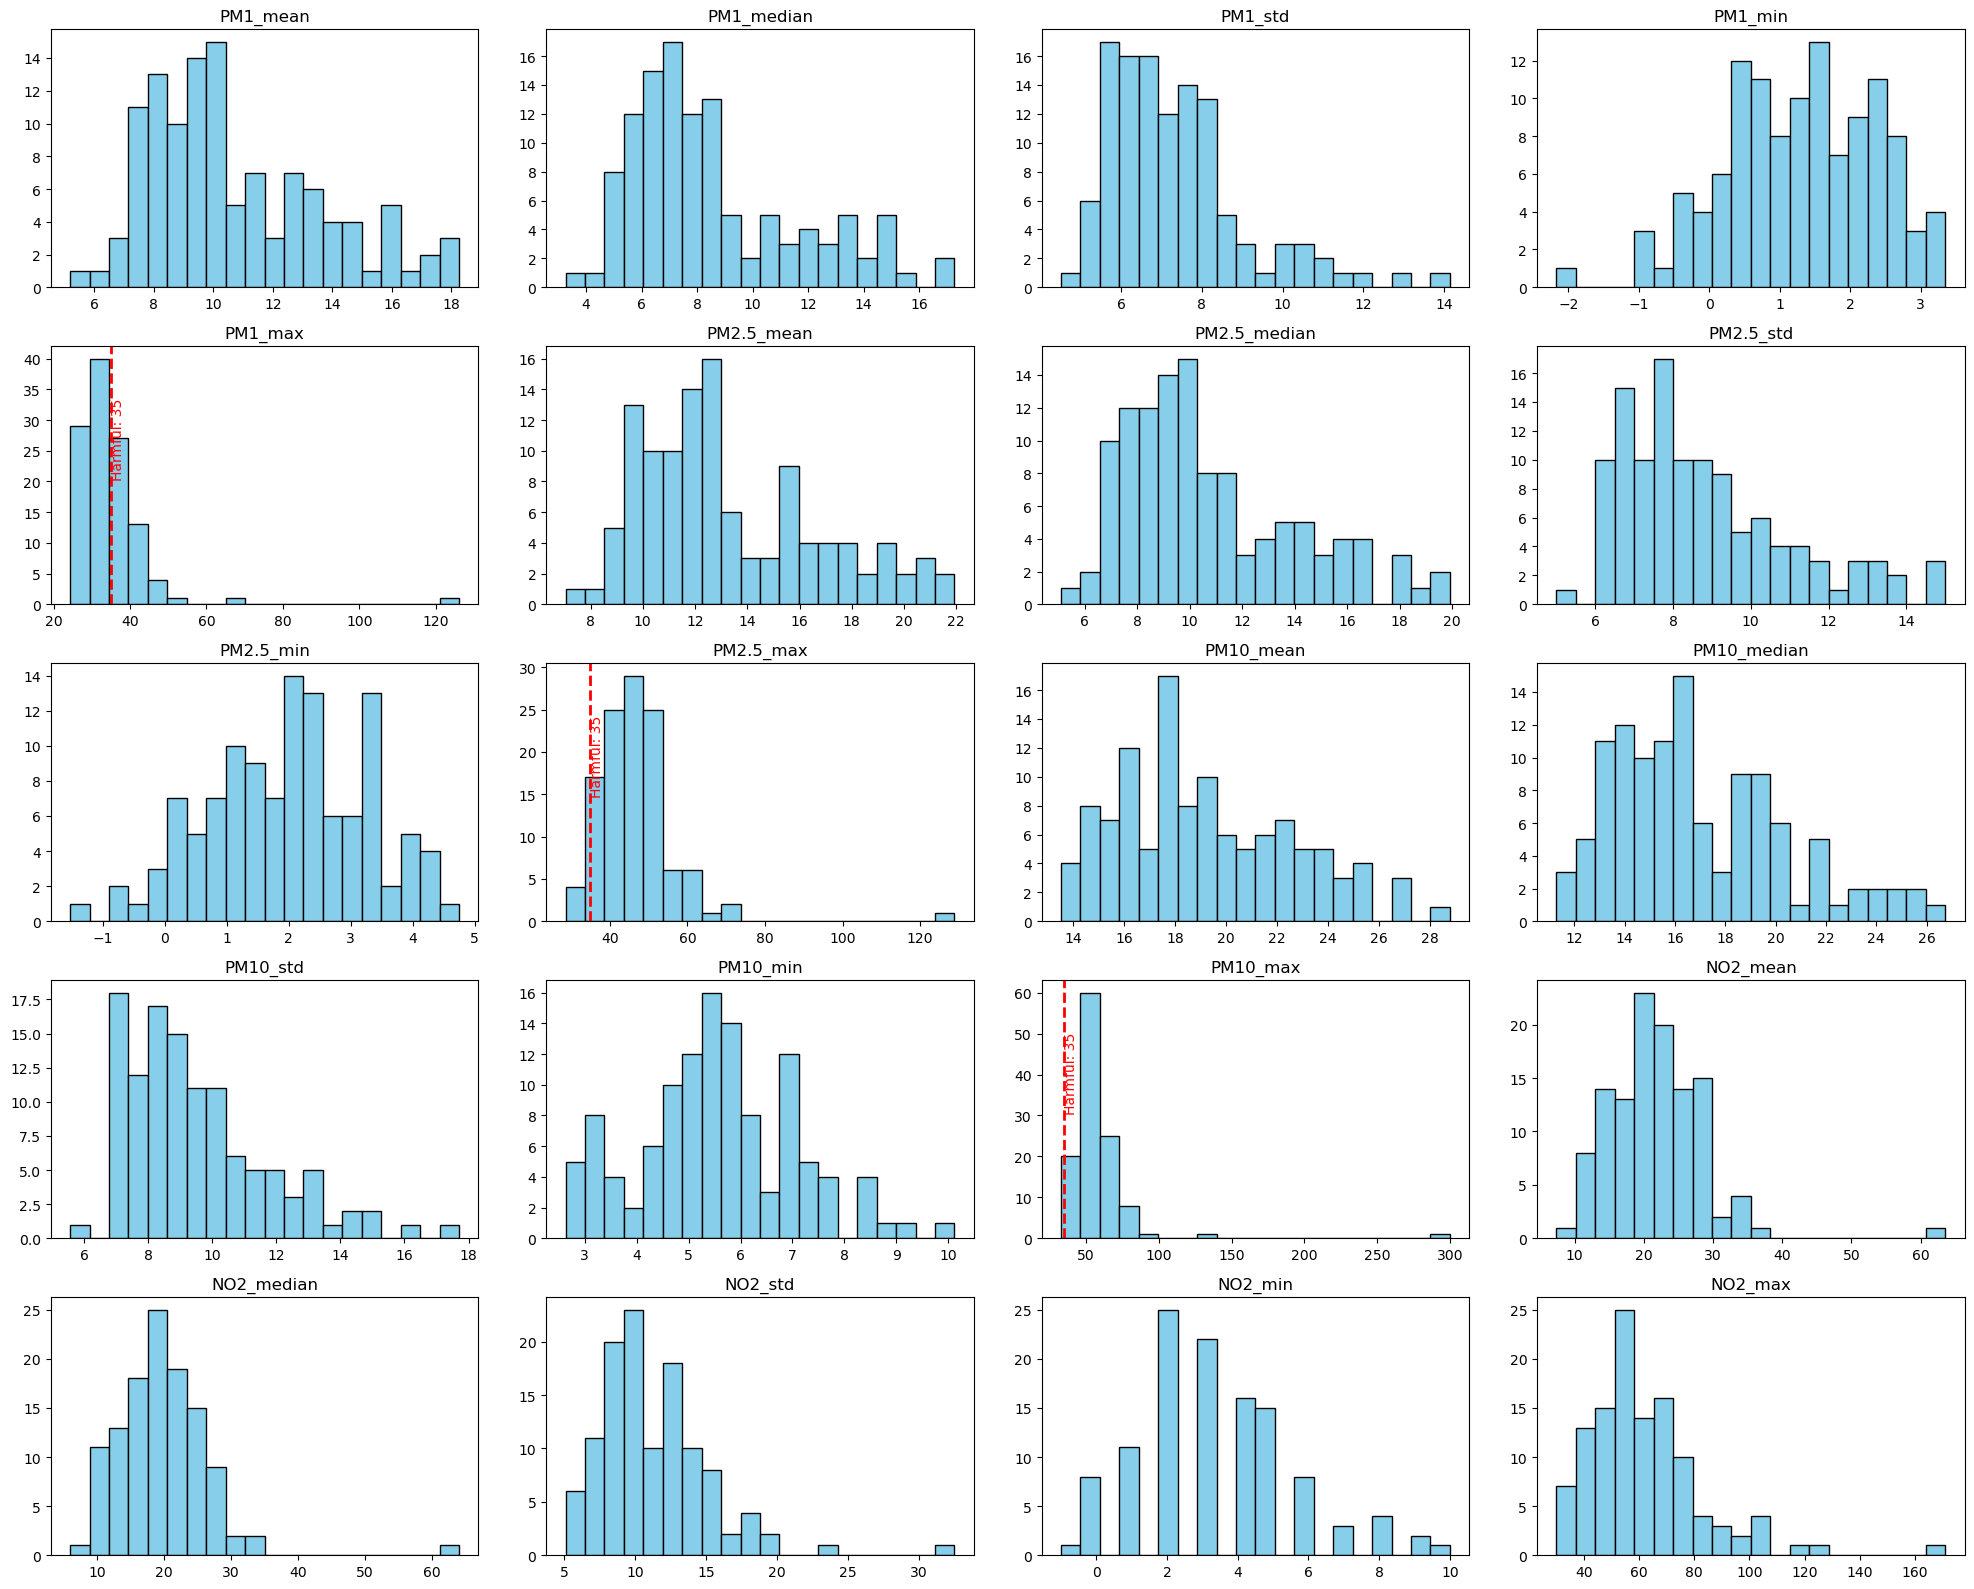

In [25]:
fig, axes = plt.subplots(5, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col]
    ax.hist(data, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(col)

    for pollutant in HAMRFUL_LEVELS:
        if pollutant in col:
            threshold = HAMRFUL_LEVELS[pollutant]
            if np.nanmin(data) <= threshold <= np.nanmax(data):
                ax.axvline(threshold, color='red', linestyle='--', linewidth=2)
                ax.text(threshold, ax.get_ylim()[1]*0.8, f'Harmful: {threshold}', color='red', rotation=90, va='top')
            break

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

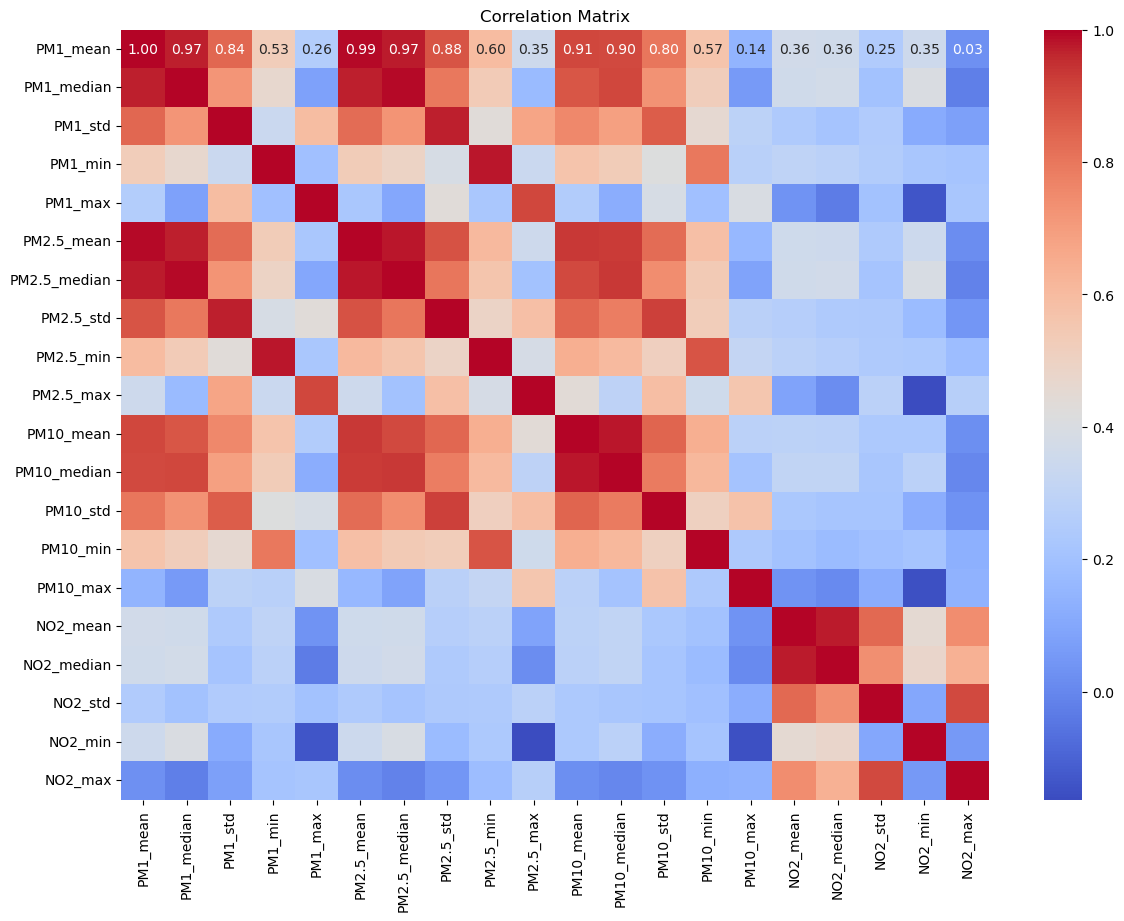

In [26]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [30]:
df['Year'] = df['Time_Local'].dt.year

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

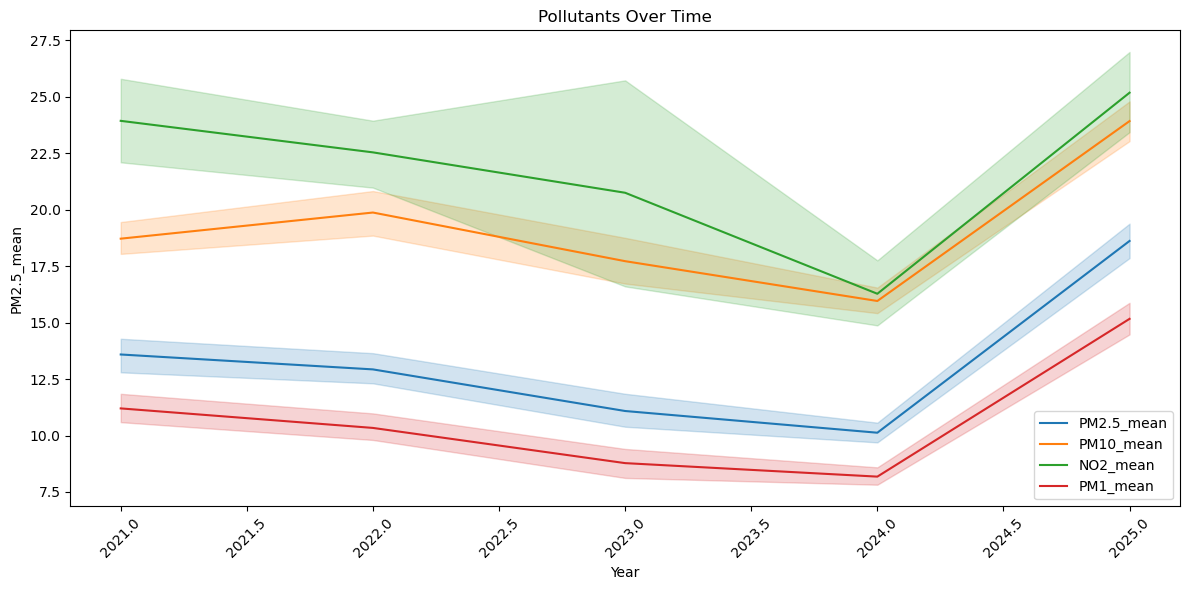

In [32]:
df = df.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 6))
for col in ["PM2.5_mean", "PM10_mean", "NO2_mean", "PM1_mean"]:
    sns.lineplot(data=df, x="Year", y=col, label=col)
plt.title("Pollutants Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

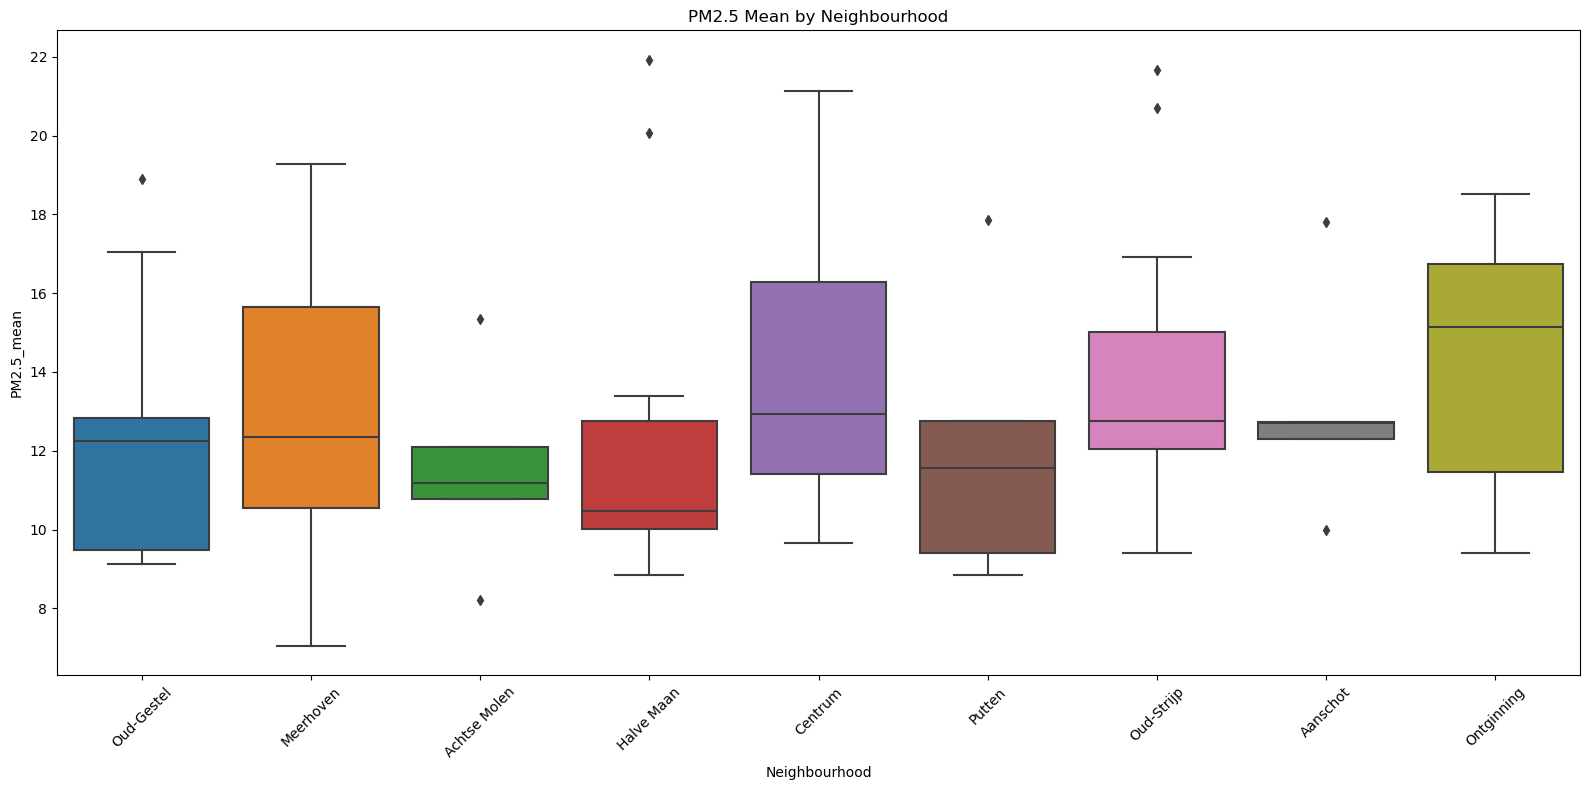

In [33]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x="Neighbourhood", y="PM2.5_mean")
plt.title("PM2.5 Mean by Neighbourhood")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()